<a href="https://colab.research.google.com/github/Harryrocks19/Data-Science-Projects/blob/main/Wine_Quality_Prediction_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/sample_data/WineQuality.csv')
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4      5.0  
1      9.8      5.0  
2      9.8      5.0 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1699 non-null   float64
 1   volatile acidity      1699 non-null   float64
 2   citric acid           1699 non-null   float64
 3   residual sugar        1699 non-null   float64
 4   chlorides             1699 non-null   float64
 5   free sulfur dioxide   1699 non-null   float64
 6   total sulfur dioxide  1699 non-null   float64
 7   density               1699 non-null   float64
 8   pH                    1699 non-null   float64
 9   sulphates             1699 non-null   float64
 10  alcohol               1699 non-null   float64
 11  quality               1699 non-null   float64
dtypes: float64(12)
memory usage: 159.4 KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1699.0,8.329397,1.726301,4.60000,7.100000,7.90000,9.20000,15.90000
volatile acidity,1699.0,0.526786,0.178695,0.12000,0.390000,0.52000,0.64000,1.58000
citric acid,1699.0,0.271403,0.194009,0.00000,0.094784,0.26000,0.42000,1.00000
residual sugar,1699.0,2.549096,1.399910,0.90000,1.900000,2.20000,2.60000,15.50000
chlorides,1699.0,0.087544,0.046900,0.01200,0.070000,0.07900,0.09100,0.61100
free sulfur dioxide,1699.0,16.048253,10.490591,1.00000,8.000000,14.00000,22.00000,72.00000
total sulfur dioxide,1699.0,46.897874,32.733365,6.00000,22.000000,38.00000,63.00000,289.00000
density,1699.0,0.996747,0.001887,0.99007,0.995600,0.99675,0.99786,1.00369
pH,1699.0,3.311263,0.154309,2.74000,3.210000,3.31000,3.40000,4.01000
sulphates,1699.0,0.657206,0.169189,0.33000,0.550000,0.62000,0.73000,2.00000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


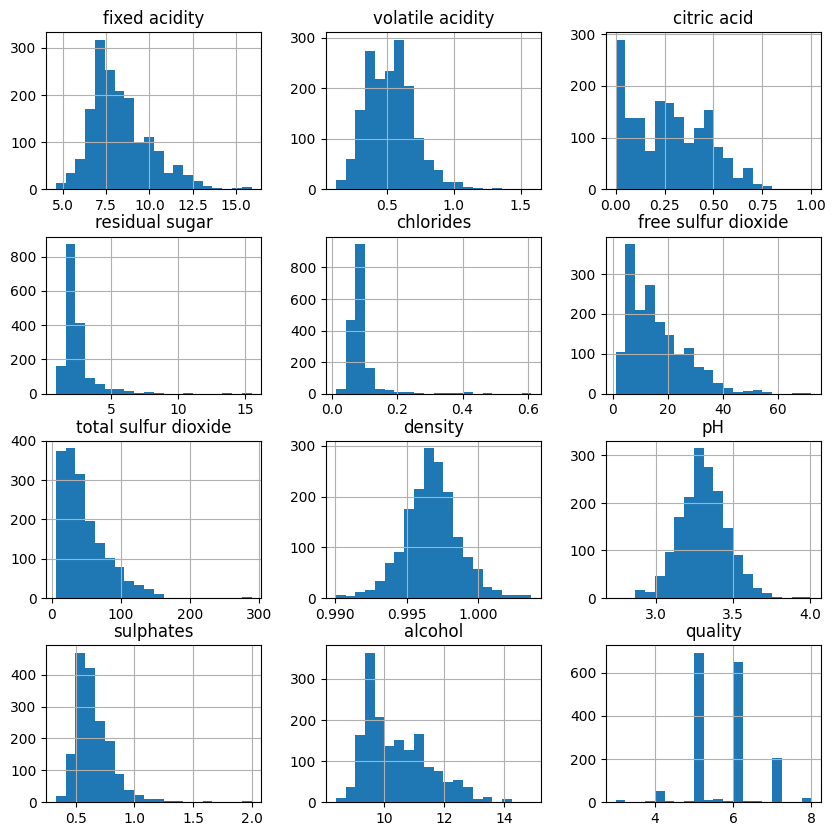

In [ ]:
df.hist(bins=20, figsize=(10,10))
plt.show()

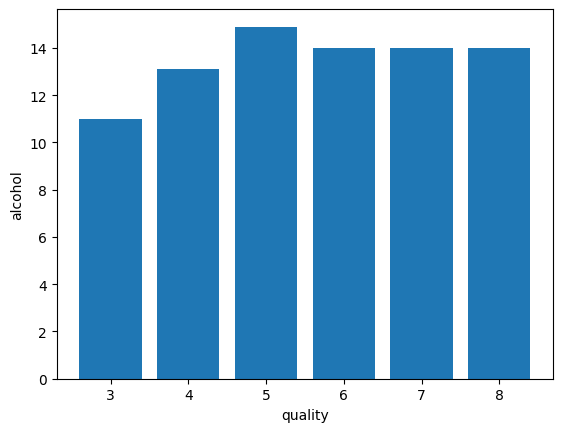

In [ ]:
plt.bar(df['quality'], df['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

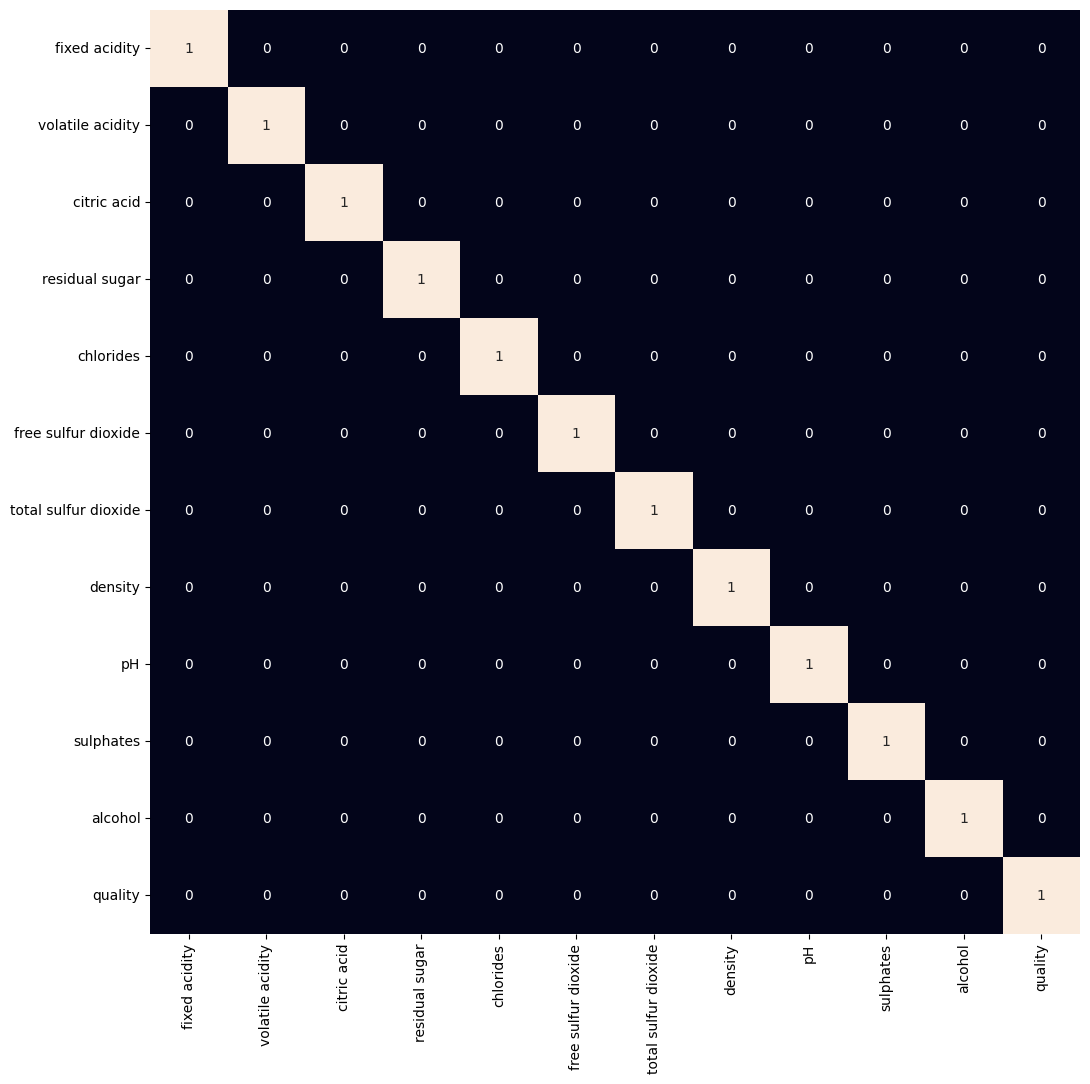

In [ ]:
for col in df.columns:
  if df[col].dtype == 'object':
    try:
      df[col] = pd.to_numeric(df[col], errors='coerce')

    except:
      pass

plt.figure(figsize=(12,12))
sb.heatmap(df.corr() > 0.7, annot=True, cbar=False)
plt.show()

In [ ]:
df = df.drop('total sulfur dioxide', axis=1)

In [ ]:
df['best quality'] = [1 if x > 5 else 0 for x in df.quality]

In [ ]:
df.replace({'white': 1, 'red': 0}, inplace=True)

In [ ]:
features = df.drop(['quality', 'best quality'], axis=1)
features = features.fillna(features.mean())
target = df['best quality']

xtrain, xtest, ytrain, ytest = train_test_split(
	features, target, test_size=0.2, random_state=40)


from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
xtrain = imputer.fit_transform(xtrain)
xtest = imputer.transform(xtest)

xtrain.shape, xtest.shape

((1359, 10), (340, 10))

In [ ]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [ ]:
models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

for i in range(3):
    models[i].fit(xtrain, ytrain)

    print(f'{models[i]} : ')
    print('Training Accuracy : ', metrics.roc_auc_score(ytrain, models[i].predict(xtrain)))
    print('Validation Accuracy : ', metrics.roc_auc_score(
        ytest, models[i].predict(xtest)))
    print()

LogisticRegression() : 
Training Accuracy :  0.7194816892316281
Validation Accuracy :  0.743965875988348

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.7538146760993203

SVC() : 
Training Accuracy :  0.7538089276990718
Validation Ac

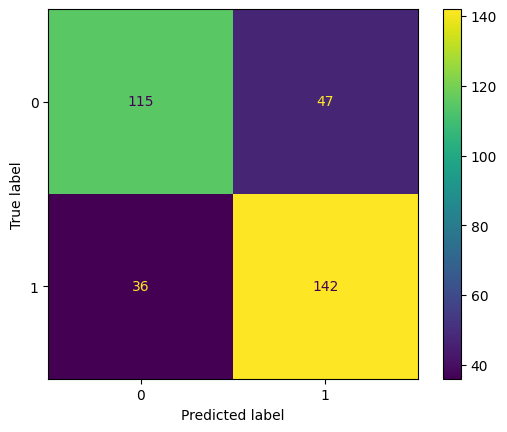

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(ytest, models[1].predict(xtest))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=models[1].classes_) # Assuming your model has a 'classes_' attribute
disp.plot()
plt.show()



In [ ]:
print(metrics.classification_report(ytest,
                                    models[1].predict(xtest)))

              precision    recall  f1-score   support

           0       0.76      0.71      0.73       162
           1       0.75      0.80      0.77       178

    accuracy                           0.76       340
   macro avg       0.76      0.75      0.75       340
weighted avg       0.76      0.76      0.76       340

